<a href="https://colab.research.google.com/github/amit-sw/colab_notebooks/blob/main/20260727_Landscape.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set up

We need to run all cells in-order from top to bottom.

Please change **TESTMODE = False** to **TESTMODE = True** during development if you want to test individual Agents.

In [ ]:
!pip install langchain_openai langgraph pydantic openai langchain_core langchain_community --quiet

In [ ]:
import os
from google.colab import userdata
OPENAI_API_KEY=userdata.get('OPENAI_API_KEY')
os.environ['OPENAI_API_KEY']=OPENAI_API_KEY
TESTMODE = False

In [ ]:
from IPython.display import display, Markdown
from openai import OpenAI
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field

import operator
from typing import Annotated

import uuid
from enum import Enum

from langchain_core.messages import SystemMessage, BaseMessage, HumanMessage, AIMessage

## Creating the graph (and testing)

We are creating the data structures for **Structured Output** from LLMs for missing information in the initial user specification.

We then define the overall Graph and then define each Agent one-by-one. For each Agent, we also write corresponding code to test the Agent in isolation.


In [ ]:
class InformationCategory(str, Enum):
    ZONE = "zone"
    WATER = "water"
    ORIENTATION = "orientation"


class InformationElement(BaseModel):
    category: InformationCategory
    description: str = Field(
        description="A concise explanation of the missing information."
    )

class InputReviewResult(BaseModel):
    is_complete: bool = Field(
        description=(
            "True when the user has provided sufficient zone, water, "
            "and orientation information."
        )
    )
    information_needed: list[InformationElement] = Field(
        description=(
            "Missing information. This must be empty when is_complete is true."
        )
    )

In [ ]:
class AgentState(BaseModel):
    """State of the agent."""
    messages: Annotated[list[dict[str, str]],operator.add] = Field(default_factory=list)
    user_spec: str = ""
    input_review: InputReviewResult | None = None
    response: str = ""
    category: str = ""
    lastAgent: str = ""
    finalDesign: str = ""

In [ ]:
class LandscapeAgent():
    """A chatbot agent that interacts with users."""

    def __init__(self, api_key: str):
        #self.model = ChatOpenAI(model_name="gpt-5-nano", openai_api_key=api_key)
        self.client = OpenAI(api_key=api_key)
        workflow = StateGraph(AgentState)
        workflow.add_node("initialInput", self.initialInput)
        workflow.add_node("inputReview", self.inputReview)
        workflow.add_node("firstDesign", self.firstDesign)
        workflow.add_node("reviewDesign", self.reviewDesign)
        workflow.add_node("finalDesign", self.finalDesign)

        workflow.add_edge(START, "initialInput")
        workflow.add_edge("initialInput", "inputReview")
        workflow.add_edge("inputReview", "firstDesign")
        workflow.add_edge("firstDesign", "reviewDesign")
        workflow.add_edge("reviewDesign", "finalDesign")
        workflow.add_edge("finalDesign", END)

        self.graph = workflow.compile()

In [ ]:
def initialInput(self, state: AgentState):
    print("Initial Input  agent processing....")
    LANDSCAPE_DESIGN_INPUT_PROMPT = f"""
    You are a master gardener.
    Good landscape design requires (a) Zone, (b) water available, (c) orientation.
    Craft a message to ask the user for this information.
    """
    response = self.client.responses.create(
        model="gpt-5-mini",
        instructions=LANDSCAPE_DESIGN_INPUT_PROMPT,
        input=state.messages,
        store=False
    )
    user_response = input(f"{response.output_text}\n")
    #print(f"DEBUG: AAAA. User response: {user_response}")

    return {"user_spec": f"{user_response}",
            "messages": [
                {"role": "assistant", "content": response.output_text},
                 {"role": "user", "content": user_response},
            ],
            "lastAgent": "inputReview"}
LandscapeAgent.initialInput = initialInput

In [ ]:
if TESTMODE:
  app=LandscapeAgent(OPENAI_API_KEY)
  test_state = AgentState(
      messages=[{"role":"user","content":"I need help with my landscape"}],
  )

  result = app.graph.nodes["initialInput"].invoke(test_state)

  print(f"Returns: {result['user_spec']}")

In [ ]:
def inputReview(self, state: AgentState):
    print("Input review agent processing....")
    user_spec=state.user_spec
    print(f"DEBUG: User spec: {user_spec}")
    INPUT_REVIEW_PROMPT = """
    Review the user's landscape-design requirements.

    Sufficient input must include:
    1. The climate or USDA hardiness zone.
    2. The amount of water available or desired irrigation level.
    3. The site's orientation or sunlight exposure.

    Set is_complete to true only when all three categories are sufficiently
    specified.

    If is_complete is true:
    - information_needed must be an empty list.

    If is_complete is false:
    - Include exactly one InformationElement for each missing or unclear category.
    - Do not include categories that are already sufficiently specified.
    - Make each description a concise question or explanation of what is needed.
    """
    msg=[]
    msg.extend(state.messages)
    new_msg={"role":"user","content":f"Review the following landscape specification:{user_spec}"}
    msg.append(new_msg)
    response = self.client.responses.parse(
        model="gpt-5-mini",
        instructions=INPUT_REVIEW_PROMPT,
        input=msg,
        text_format=InputReviewResult,
        store=False
    )
    #llm_messages1 = create_openai_msg(SMALLTALK_PROMPT, state.messages)
    review=response.output_parsed
    if(review.is_complete):
      print("AAA DEBUG:", review.model_dump(mode="json"))
      return {"input_review": review,
              "messages": [
                  {
                    "role": "assistant",
                    "content": "Thanks—your landscape requirements are complete.",
                    }
                ],
              "lastAgent": "inputReview"}
    follow_up_question=review.information_needed[0].description
    extra_info=input(follow_up_question)
    extra_msg={"role":"user","content":extra_info}
    msg.append(extra_msg)
    response2 = self.client.responses.parse(
        model="gpt-5-mini",
        instructions=INPUT_REVIEW_PROMPT,
        input=msg,
        text_format=InputReviewResult,
        store=False
    )
    review2=response2.output_parsed
    new_turns = [
        {"role": "assistant", "content": follow_up_question},
        {"role": "user", "content": extra_info},
        #{"role": "assistant", "content": review2},
    ]
    #print("BBB DEBUG:", review.model_dump(mode="json"))
    print("Finished Input review agent")
    return { #"input_review": review,"extra_info":extra_info,"input_review2": review2,
            "messages": new_turns,
            "lastAgent": "inputReview"}
LandscapeAgent.inputReview = inputReview

In [ ]:
if TESTMODE:
  app=LandscapeAgent(OPENAI_API_KEY)
  test_state = AgentState(
      messages=[
          {'role': 'assistant',
          'content': 'Great — I can help. To design something that will thrive I need three key facts:\n\n1) Zone — your plant hardiness zone (USDA or Sunset) or your ZIP/postal code and nearest city/state so I can look it up for you.  \n2) Water available — your water source (municipal, well, rain-harvest, greywater), whether you have irrigation (drip, sprinkler, none), any watering limits or drought restrictions, and whether you prefer low-water/ xeriscape plants.  \n3) Orientation — which way the yard/bed faces (which side of the house is north/south/east/west), typical sun/shade patterns through the day (full sun, morning sun/afternoon shade, full shade), and whether the site is flat or sloped.\n\nIf you don’t know some of these, that’s fine — you can send a photo, a simple sketch, or your general location and I’ll help figure it out. Also tell me any preferences (style, maintenance level, pets/kids, budget) so the plan fits your needs.'},
          {'role': 'user', 'content': 'Zone 3. Looks east.'}
          ],
      user_spec="""
          Zone 3. Looks east.
      """,
  )

  result = app.graph.nodes["inputReview"].invoke(test_state)

  result

In [ ]:
def firstDesign(self, state: AgentState):
    print("First Design  agent processing....")
    FIRST_DESIGN_PROMPT="""
    Create a fully-formed landscape design suggestion.

    If possible, factor in:
    1. The climate or USDA hardiness zone.
    2. The amount of water available or desired irrigation level.
    3. The site's orientation or sunlight exposure.

    We want to use native plants as much as possible, and not use too much water for irrigation.
    """
    msg=[]
    msg.extend(state.messages)
    #new_msg={"role":"user","content":f"Review the following landscape specification:{user_spec}"}
    #msg.append(new_msg)
    response = self.client.responses.create(
        model="gpt-5-mini",
        instructions=FIRST_DESIGN_PROMPT,
        input=msg,
        store=False
    )
    #llm_response = response.output_text

    return {
            "messages": [
                {"role": "assistant", "content": FIRST_DESIGN_PROMPT},
                {"role": "assistant", "content": response.output_text},
            ],
            "lastAgent": "firstDesign"}
LandscapeAgent.firstDesign = firstDesign

In [ ]:
if TESTMODE:
  app=LandscapeAgent(OPENAI_API_KEY)
  test_state = AgentState(
      messages=[
          {'role': 'assistant',
          'content': 'Great — I can help. To design something that will thrive I need three key facts:\n\n1) Zone — your plant hardiness zone (USDA or Sunset) or your ZIP/postal code and nearest city/state so I can look it up for you.  \n2) Water available — your water source (municipal, well, rain-harvest, greywater), whether you have irrigation (drip, sprinkler, none), any watering limits or drought restrictions, and whether you prefer low-water/ xeriscape plants.  \n3) Orientation — which way the yard/bed faces (which side of the house is north/south/east/west), typical sun/shade patterns through the day (full sun, morning sun/afternoon shade, full shade), and whether the site is flat or sloped.\n\nIf you don’t know some of these, that’s fine — you can send a photo, a simple sketch, or your general location and I’ll help figure it out. Also tell me any preferences (style, maintenance level, pets/kids, budget) so the plan fits your needs.'},
          {'role': 'user', 'content': 'Zone 3. Looks east.'},
          {'role': 'assistant',
          'content': 'Please specify water availability and desired irrigation level (municipal/well/rainwater/none), irrigation type if any (drip/sprinkler/none), any watering restrictions, or whether you prefer low‑water/xeriscape planting.'},
            {'role': 'user', 'content': 'Drip irrigation'},
          ],
      user_spec="""
          Zone 3. Looks east.
      """,
  )

  result = app.graph.nodes["firstDesign"].invoke(test_state)

  result

In [ ]:
def reviewDesign(self, state: AgentState):
    print(" reviewDesign  agent processing....")

    REVIEW_DESIGN_PROMPT="""
    Review the proposed design. In particular, focus on

    1. No citrus fruits - they taste bad
    2. Only perenial flowers

    Provide a short succint feedback with recommended changes.
    """
    msg=[]
    msg.extend(state.messages)
    #new_msg={"role":"user","content":f"Review the following landscape specification:{user_spec}"}
    #msg.append(new_msg)
    response = self.client.responses.create(
        model="gpt-5-mini",
        instructions=REVIEW_DESIGN_PROMPT,
        input=msg,
        store=False
    )
    #llm_response = response.output_text

    return {
            "messages": [
                {"role": "assistant", "content": REVIEW_DESIGN_PROMPT},
                {"role": "assistant", "content": response.output_text},
            ],
            "lastAgent": "reviewDesign"}
LandscapeAgent.reviewDesign = reviewDesign



In [ ]:
if TESTMODE:
  app=LandscapeAgent(OPENAI_API_KEY)
  test_state = AgentState(
      messages=[
          {'role': 'assistant',
          'content': 'Great — I can help. To design something that will thrive I need three key facts:\n\n1) Zone — your plant hardiness zone (USDA or Sunset) or your ZIP/postal code and nearest city/state so I can look it up for you.  \n2) Water available — your water source (municipal, well, rain-harvest, greywater), whether you have irrigation (drip, sprinkler, none), any watering limits or drought restrictions, and whether you prefer low-water/ xeriscape plants.  \n3) Orientation — which way the yard/bed faces (which side of the house is north/south/east/west), typical sun/shade patterns through the day (full sun, morning sun/afternoon shade, full shade), and whether the site is flat or sloped.\n\nIf you don’t know some of these, that’s fine — you can send a photo, a simple sketch, or your general location and I’ll help figure it out. Also tell me any preferences (style, maintenance level, pets/kids, budget) so the plan fits your needs.'},
          {'role': 'user', 'content': 'Zone 3. Looks east.'},
          {'role': 'assistant',
          'content': 'Please specify water availability and desired irrigation level (municipal/well/rainwater/none), irrigation type if any (drip/sprinkler/none), any watering restrictions, or whether you prefer low‑water/xeriscape planting.'},
            {'role': 'user', 'content': 'Drip irrigation'},
          {'role': 'assistant',
          'content': '''
              Thanks — I’ll assume you want a low‑water, mostly‑native planting for an east‑facing site in USDA Zone 3
              with drip irrigation. I’ll give a complete, ready‑to‑use design for a typical mid‑size planting bed
              (about 20 ft long × 12 ft deep) that gets strong morning sun and afternoon shade (typical “east” exposure).
              If your space is much larger/smaller or you want a different use (lawn replacement, rain garden, privacy screen),
              tell me and I’ll adapt.\n\nDesign goals\n- Use mostly regionally native, cold‑hardy (Zone 3) plants.\n-
              Low supplemental irrigation once established (drip used for establishment and occasional deep watering).\n
              - Wildlife and pollinator value, seasonal interest (spring flowers, summer blooms, fall color, winter structure).\n
              - Low maintenance: mulched, grouped by water need, minimal fertilizer.\n\nSite plan (20\' × 12\') — concept\n
              - Back row (near structure or fence, 6–8 ft from edge): 1 small native tree + 2–3 medium shrubs
              for structure and spring interest.\n- Mid row (4–6 ft tall shrubs/perennials):
                massed shrubs and taller perennials for summer color.\n- Front row (low perennials/groundcovers/ornamental grasses):
                groundcovers and clumping grasses for texture and low water use.\n- Mulch 2–3" with wood chips or shredded bark;
                place drip lines in separate zones (establishment vs. long‑term low‑water plants).\n\nPlant palette
                (Zone 3, tolerant of morning sun/afternoon shade, low water once established)\n
                Trees / large shrubs\n- Amelanchier alnifolia (Saskatoon/serviceberry) — small tree, spring white flowers,
                edible berries, excellent wildlife value. Plant 1 at back center.
                Spacing: 12–18 ft mature but single specimen here.\n\nMedium shrubs\n
                - Cornus sericea (red‑osier dogwood) — winter twig color, tolerates partial shade;
                plant 2 at rear corners or staggered. (Can be cut back for stems.)\n
                - Potentilla fruticosa (shrubby cinquefoil) — sunny/part‑shade tolerant, long bloom, very drought resistant;
                plant 2–3 in mid row.\n- Shepherdia canadensis (buffaloberry) — very drought tolerant, wildlife value;
                1–2 if you want fruiting shrub.\n\nPerennials (fill mid and front rows)\n
                - Echinacea angustifolia / Echinacea purpurea (purple coneflower) — pollinator magnet; tolerates some shade
                but likes morning sun.\n- Rudbeckia hirta (black‑eyed Susan) — long bloom, drought tolerant.\n
                - Solidago spp. (goldenrod) — late‑season nectar, partial shade tolerant.\n- Aster spp. (Symphyotrichum spp.) —
                fall blooms, good in partial shade.\n
                - Heuchera richardsonii (native alumroot) or Heuchera americana (where appropriate) — good front row, shade tolerant.
                '''},
          ],
      user_spec="""
          Zone 3. Looks east.
      """,
  )

  result = app.graph.nodes["reviewDesign"].invoke(test_state)

  result

In [ ]:
def finalDesign(self, state: AgentState):
    print(" finalDesign  agent processing....")
    FINAL_DESIGN_PROMPT="""
    Create a final design, based on all the discussion so far.
    """
    msg=[]
    msg.extend(state.messages)
    #new_msg={"role":"user","content":f"Review the following landscape specification:{user_spec}"}
    #msg.append(new_msg)
    response = self.client.responses.create(
        model="gpt-5-mini",
        instructions=FINAL_DESIGN_PROMPT,
        input=msg,
        store=False
    )
    #llm_response = response.output_text

    return {
            "messages": [
                {"role": "assistant", "content": FINAL_DESIGN_PROMPT},
                {"role": "assistant", "content": response.output_text},
            ],
            "finalDesign":response.output_text,
            "lastAgent": "finalDesign"}
LandscapeAgent.finalDesign = finalDesign

In [ ]:
if TESTMODE:
  app=LandscapeAgent(OPENAI_API_KEY)
  test_state = AgentState(
      messages=[
          {'role': 'assistant',
          'content': 'Great — I can help. To design something that will thrive I need three key facts:\n\n1) Zone — your plant hardiness zone (USDA or Sunset) or your ZIP/postal code and nearest city/state so I can look it up for you.  \n2) Water available — your water source (municipal, well, rain-harvest, greywater), whether you have irrigation (drip, sprinkler, none), any watering limits or drought restrictions, and whether you prefer low-water/ xeriscape plants.  \n3) Orientation — which way the yard/bed faces (which side of the house is north/south/east/west), typical sun/shade patterns through the day (full sun, morning sun/afternoon shade, full shade), and whether the site is flat or sloped.\n\nIf you don’t know some of these, that’s fine — you can send a photo, a simple sketch, or your general location and I’ll help figure it out. Also tell me any preferences (style, maintenance level, pets/kids, budget) so the plan fits your needs.'},
          {'role': 'user', 'content': 'Zone 3. Looks east.'},
          {'role': 'assistant',
          'content': 'Please specify water availability and desired irrigation level (municipal/well/rainwater/none), irrigation type if any (drip/sprinkler/none), any watering restrictions, or whether you prefer low‑water/xeriscape planting.'},
            {'role': 'user', 'content': 'Drip irrigation'},
          {'role': 'assistant',
          'content': '''
              Thanks — I’ll assume you want a low‑water, mostly‑native planting for an east‑facing site in USDA Zone 3
              with drip irrigation. I’ll give a complete, ready‑to‑use design for a typical mid‑size planting bed
              (about 20 ft long × 12 ft deep) that gets strong morning sun and afternoon shade (typical “east” exposure).
              If your space is much larger/smaller or you want a different use (lawn replacement, rain garden, privacy screen),
              tell me and I’ll adapt.\n\nDesign goals\n- Use mostly regionally native, cold‑hardy (Zone 3) plants.\n-
              Low supplemental irrigation once established (drip used for establishment and occasional deep watering).\n
              - Wildlife and pollinator value, seasonal interest (spring flowers, summer blooms, fall color, winter structure).\n
              - Low maintenance: mulched, grouped by water need, minimal fertilizer.\n\nSite plan (20\' × 12\') — concept\n
              - Back row (near structure or fence, 6–8 ft from edge): 1 small native tree + 2–3 medium shrubs
              for structure and spring interest.\n- Mid row (4–6 ft tall shrubs/perennials):
                massed shrubs and taller perennials for summer color.\n- Front row (low perennials/groundcovers/ornamental grasses):
                groundcovers and clumping grasses for texture and low water use.\n- Mulch 2–3" with wood chips or shredded bark;
                place drip lines in separate zones (establishment vs. long‑term low‑water plants).\n\nPlant palette
                (Zone 3, tolerant of morning sun/afternoon shade, low water once established)\n
                Trees / large shrubs\n- Amelanchier alnifolia (Saskatoon/serviceberry) — small tree, spring white flowers,
                edible berries, excellent wildlife value. Plant 1 at back center.
                Spacing: 12–18 ft mature but single specimen here.\n\nMedium shrubs\n
                - Cornus sericea (red‑osier dogwood) — winter twig color, tolerates partial shade;
                plant 2 at rear corners or staggered. (Can be cut back for stems.)\n
                - Potentilla fruticosa (shrubby cinquefoil) — sunny/part‑shade tolerant, long bloom, very drought resistant;
                plant 2–3 in mid row.\n- Shepherdia canadensis (buffaloberry) — very drought tolerant, wildlife value;
                1–2 if you want fruiting shrub.\n\nPerennials (fill mid and front rows)\n
                - Echinacea angustifolia / Echinacea purpurea (purple coneflower) — pollinator magnet; tolerates some shade
                but likes morning sun.\n- Rudbeckia hirta (black‑eyed Susan) — long bloom, drought tolerant.\n
                - Solidago spp. (goldenrod) — late‑season nectar, partial shade tolerant.\n- Aster spp. (Symphyotrichum spp.) —
                fall blooms, good in partial shade.\n
                - Heuchera richardsonii (native alumroot) or Heuchera americana (where appropriate) — good front row, shade tolerant.
                '''},
          {'role': 'assistant',
          'content': '''
          Short summary\n- Got it: no citrus (not relevant in Zone 3 anyway) and only perennial flowering plants —
          remove the trees and shrubs from the original plan and replace them with cold‑hardy perennials,
          grasses and bulbs that perform in USDA Zone 3, east exposure, on drip irrigation.\n\nRecommended changes
          (concise)\n1. Remove woody plants: delete Amelanchier, Cornus, Potentilla, Shepherdia. These are shrubs/trees
          and violate the “only perennial flowers” rule.\n2. Replace structure with tall perennial groups and clumping
          ornamental grasses to provide height, winter structure and seasonal interest.\n3. Choose a succession of
          perennials to give spring → summer → fall blooms so you still get long season interest without shrubs.\n4.
          Keep drip irrigation but zone it: one zone for initial establishment (more frequent), then a low‑water zone
          for mature plants (deep, infrequent watering).\n\nProposed plant palette (Zone 3, east exposure, low water
          once established) — all perennial flowers/grasses/bulbs\n- Tall (back row / 3–4+ ft)\n  - Echinacea purpurea
          or E. angustifolia (purple coneflower) — pollinator magnet, summer.\n  - Rudbeckia fulgida / R. hirta (black‑eyed Susan) —
          long summer bloom.\n  - Penstemon strictus or P. digitalis (penstemon) — spring–early summer spikes.\n
          - Baptisia australis (false indigo) — spring/early summer structural blooms.\n- Mid (1.5–3 ft)\n
          - Solidago spp. (goldenrod) — late summer/fall nectar.\n  - Symphyotrichum spp. (asters) — fall color/blooms.\n
          - Achillea millefolium (yarrow) — summer, drought tolerant.\n  - Geranium sanguineum / hardy cranesbill —
          long bloom, tidy habit.\n- Front / low (6–18 in)\n  - Heuchera (alumroot) — foliage interest, shade tolerant.\n
          - Sedum spurium / Sedum telephium (stonecrop) — late summer, very low water.\n  - Phlox subulata (creeping phlox)
          or Phlox stolonifera — spring color.\n  - Allium spp. (ornamental onion bulbs) — spring accents (bulbs are perennial).\n
          - Grasses/structure (interspersed)\n  - Calamagrostis x acutiflora ‘Karl Foerster’ or Festuca idahoensis (clumping fescue)
          — winter form, texture (many are Zone 3 hardy).\n\nLayout suggestion for your 20\' × 12\' bed (brief)\n
          - Back row: repeat blocks of tall perennials (group 3–5 of same species for impact) spaced per mature width.\n
          - Mid row: masses of mid‑height perennials alternating species for succession and diversity.\n
          - Front: tight groups of low sedum, phlox and heuchera; plant allium bulbs among them for spring pop.\n
          - Interplant clumps of ornamental grass every 6–8 ft for vertical rhythm and winter interest.\n\n
          Planting density & counts (approx. for 20\'×12\')\n- Echinacea: 6 plants (spaced ~2–2.5 ft)'''},

          ],
      user_spec="""
          Zone 3. Looks east.
      """,
  )

  result = app.graph.nodes["finalDesign"].invoke(test_state)

  result

In [ ]:
app=LandscapeAgent(OPENAI_API_KEY)
list(app.graph.nodes)

['__start__',
 'initialInput',
 'inputReview',
 'firstDesign',
 'reviewDesign',
 'finalDesign']

# Run the graph

We see both the final landscape design created, as well as the internal flow of messages.

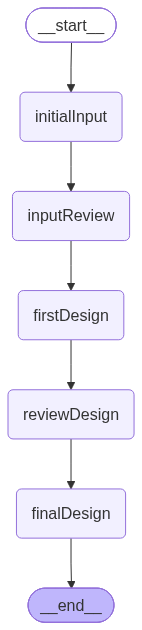

In [ ]:
app=LandscapeAgent(OPENAI_API_KEY)
from IPython.display import Image
Image(app.graph.get_graph().draw_mermaid_png())

In [ ]:
from IPython.display import display, Markdown

app = LandscapeAgent(OPENAI_API_KEY)
msg_list=[{"role": "user","content": "I need help with my landscape."}]
result = app.graph.invoke({"messages": msg_list})

final_design = result.get("finalDesign")

if final_design:
    display(Markdown("### Final landscape design"))
    display(Markdown(final_design))

messages = result["messages"]

Initial Input  agent processing....
Great — I can help. To design something that will thrive, I need three key facts from you. Could you tell me:

1. Zone (USDA hardiness zone or your city/ZIP): this tells me what plants will survive your winters. If you don’t know it, give your town or ZIP and I’ll look it up.  
2. Water available: do you have municipal water, a well, drip irrigation, only hand-watering, or restrictions (city watering days, drought rules)? If possible say roughly how often you’ll/want to water (daily/weekly/only rainy season).  
3. Orientation and sun exposure: which directions do the main beds face (front yard faces north/south/east/west)? Describe how many hours of sun each area gets (full sun = ~6+ hrs, part shade, full shade) or send a quick note like “back yard 8 hrs sun, north side shaded.”

Optional but helpful: property size or bed dimensions, soil type (clay/sandy/loamy), photos or a simple sketch, and your design goals (low-maintenance, pollinator garden, ed

### Final landscape design

Final landscape design — Zone 4, north‑facing, windy, hand‑watered, mostly native, perennial‑only

Design concept (short)
- Layered, wind‑tolerant native planting: multi‑stem shrubs/ small trees at the north (windward) edge to reduce wind and create microclimates; medium shrubs in the middle for structure and fruit/seasonal interest; shade/part‑shade perennial flowers, sedges and groundcovers in the front.  
- All recommended plants are hardy to USDA Zone 4 and are perennial or woody perennials (no citrus, no annuals). Designed to be low‑water once established and practical for hand‑watering.

Plant palette by layer (native, perennial/woody only)
- Back / wind buffer (small trees & large shrubs)
  - Amelanchier spp. (Serviceberry) — spring flowers, edible berries for wildlife.  
  - Cornus sericea (Red‑osier dogwood) — tough, multi‑stemmed wind buffer.  
  - Viburnum dentatum or Viburnum trilobum (Arrowwood / Highbush cranberry) — berries, winter structure.

- Middle / structural shrubs
  - Aronia melanocarpa (Black chokeberry) — dense, flowers and berries, drought tolerant once established.  
  - Symphoricarpos albus (Common snowberry) — shade tolerant, good for fill and wildlife.  
  - Viburnum cassinoides or Viburnum recognitum (if available locally) — alternative native viburnums for shade.

- Front / perennials & groundcovers (shade/part‑shade)
  - Carex pensylvanica (Pennsylvania sedge) — primary turf alternative and drought‑tolerant groundcover for dry shade.  
  - Heuchera americana (Alumroot) — shade tolerant, long season foliage interest.  
  - Aquilegia canadensis (Columbine) — spring flowers, part shade.  
  - Geranium maculatum (Wild geranium) — shade tolerant, spring bloom.  
  - Tiarella cordifolia (Foamflower) — spring bloom, good for moist shade pockets.  
  - Eurybia divaricata or Symphyotrichum cordifolium (Wood asters) — late summer/fall color in shade.  
  - Viola sororia (Native violets) — early spring flowers and groundcover.  
  - Maianthemum canadense (False lily‑of‑the‑valley) — woodland groundcover for cool shade.  
  - Dryopteris marginalis (Marginal shield fern) or Athyrium filix‑femina (Lady fern) — for moister shaded microzones.

Notes on goldenrod/solidago: many species prefer sun; avoid large stands of goldenrod in a mostly shady northern bed. Use wood asters and asters instead for fall color in shade.

Sample planting layout (modular templates)
- Small bed ~10 ft long x 6 ft deep
  - Back: 1 Cornus sericea (center rear).  
  - Middle: 2 Aronia (staggered).  
  - Front: 6–8 Carex pensylvanica plugs forming a swath, plus 1–2 Heuchera, 3 Aquilegia, 3 Geranium in groups.

- Medium bed ~30 ft long x 8 ft deep (naturalistic drift style)
  - Back row (wind buffer): 2 Amelanchier + 2 Cornus sericea spaced 8–12 ft apart in staggered pattern.  
  - Middle: alternating Aronia (4) and Symphoricarpos (3), 4–6 ft spacing.  
  - Front: drifts of perennials — Carex mats along full front edge (space 6–12" apart), groups of Heuchera (6), Aquilegia (6), Geranium (6), Tiarella clusters (4). Add 8–10 small ferns/aster plugs for texture. Plant in groups of 5–9 for best visual impact.

Spacing rules
- Shrubs/trees: space at their mature width (typically 6–12 ft for back row shrubs/trees).  
- Medium shrubs: 3–6 ft spacing.  
- Perennials: plant in drifts 1–2 ft apart depending on mature spread; Carex plugs 6–12 in.

Soil prep & planting
- If soil is compacted or poor: mix 20–30% compost into backfill for planting holes only (don’t over‑amend entire bed). Preserve good drainage.  
- Plant the root flare at soil grade. Form a shallow saucer around each plant to hold water during hand‑watering.  
- Mulch 2–3 in (shredded bark or wood chips). Keep mulch away from direct contact with trunks/stems.

Hand‑watering & establishment schedule
- Immediately after planting: deep soak.  
- Weeks 1–2: water deeply every 3–4 days (or when top 1–2 in of soil is dry).  
- Remainder of 1st season: deep soak weekly (soak to 6–12 in depth).  
- 2nd season onward: taper to every 10–21 days depending on rainfall and heat/wind. Check soil moisture—windy summers will increase need. Use a deep, slow soak rather than frequent shallow watering.

Maintenance (low effort)
- Replenish mulch annually; add 1–2 in compost topdressing in spring if needed.  
- Prune dead wood in late winter/early spring. Thin shrubs every few years to maintain air flow.  
- Divide clumping perennials every 3–4 years as needed.  
- Monitor for invasive weeds and remove promptly.

Wind‑specific recommendations
- Use multi‑stem, permeable plantings (dogwood, serviceberry) instead of a dense solid wall—this reduces turbulence.  
- Consider a permeable slatted fence or espaliered shrub line if wind is severe; allow ~30–50% porosity for best windbreak performance.  
- Place wind‑sensitive perennials in the lee of shrubs for protection.

Seasonal interest & wildlife value
- Spring: serviceberry & columbine; violets and foamflower.  
- Summer: foliage interest from Heuchera, sedge and shrubs; berries forming.  
- Fall: viburnum/chokeberry berries and aster fall blooms; good for birds and pollinators.

Materials/shopping checklist (starter for a medium bed)
- 2 Amelanchier spp. (small tree)  
- 2 Cornus sericea  
- 4 Aronia melanocarpa  
- 3 Symphoricarpos albus  
- Carex pensylvanica — 30–50 plugs (to fill front edge)  
- Heuchera americana — 6 plants  
- Aquilegia canadensis — 6 plants  
- Geranium maculatum — 6 plants  
- Tiarella cordifolia — 4 plants  
- Eurybia divaricata / Symphyotrichum cordifolium — 8 plugs  
- Native ferns (4–6) and Viola/ Maianthemum patches as desired  
- 2–3 yd3 shredded bark mulch, compost for planting

What I still need (to perfect the plan)
- Exact bed dimensions (length, depth), a photo, and your state/city to make the plant list strictly local‑native (some species vary regionally). If you give dimensions I’ll produce a scaled layout with exact spacings and a shopping list tailored to your yard.

If you want, I can now:
- Turn this into a scaled planting map for a specified bed size, or  
- Produce a local‑native plant list (state/city) to ensure all picks are native to your ecoregion.

Which would you like next?

# To see the various messages during the Agentic run

In [ ]:
import json

print(json.dumps(messages, indent=2))

[
  {
    "role": "user",
    "content": "I need help with my landscape."
  },
  {
    "role": "assistant",
    "content": "Great \u2014 I can help. To design something that will thrive, I need three key facts from you. Could you tell me:\n\n1. Zone (USDA hardiness zone or your city/ZIP): this tells me what plants will survive your winters. If you don\u2019t know it, give your town or ZIP and I\u2019ll look it up.  \n2. Water available: do you have municipal water, a well, drip irrigation, only hand-watering, or restrictions (city watering days, drought rules)? If possible say roughly how often you\u2019ll/want to water (daily/weekly/only rainy season).  \n3. Orientation and sun exposure: which directions do the main beds face (front yard faces north/south/east/west)? Describe how many hours of sun each area gets (full sun = ~6+ hrs, part shade, full shade) or send a quick note like \u201cback yard 8 hrs sun, north side shaded.\u201d\n\nOptional but helpful: property size or bed dimens